# Dutch National Flag (3‑Way Partitioning)

**Problems**: Given an array containing only 0’s, 1’s, and 2’s, sort it in linear time O(1) and using constant space.

The idea is to partition the array into three regions based on a pivot  (here pivot = 1).

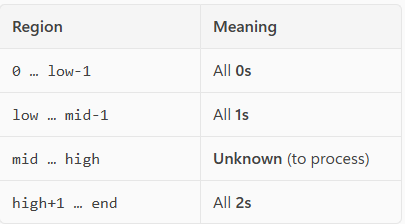

The algorithm uses three pointers:
* `low` → boundary of the region 0.
* `mid` → current element we are inspecting
* `high` → boundary of the region 2.


## Intuition (Why this works)

Think of the array like **three color buckets** (0 = Red, 1 = White, 2 = Blue).

Your job: **separate colors using only one pass.**

You inspect one element at a time:
* **If the current element is 0**: It belongs to the `start` → swap it with `low`, expand the **0‑region**, move forward.
* **If it is 1**: It is already in the middle → just move forward.
* **If it is 2**
    * It belongs to the `end` → swap with `high`, shrink the **2‑region**.
    * Don’t move `mid` yet, because the swapped element needs to be evaluated.

This ensures:
* All 0s move to the left
* All 2s move to the right
* 1's naturally remain in the middle
* No extra space is used
* Only one traversal is needed → O(n)

## Why not use sorting?

Sorting would take:
* O(n log n) time
* Or extra memory if using counting sort

But since the array contains only **three distinct values** `(0, 1, 2)`, a custom linear‑time approach is optimal.

## Visual Walkthrough Example

**Array**: `[2, 0, 2, 1, 1, 0]`

**Pointers initially**: `low = 0`, `mid = 0`, `high = 5`

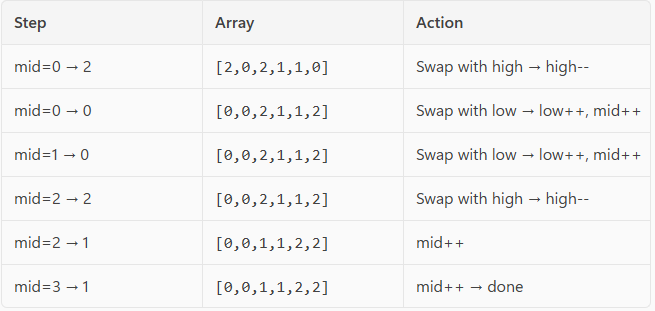

Sorted in one pass.

## Why this is a pattern, not a trick

This pattern applies to many variations:
* Sort array of colors/labels
* Partition around pivot (like Quicksort’s partition)
* Arrange negatives / zeros / positives
* Group people by category (kids, adults, seniors)
* Group objects by priority levels

Recognizing this **three‑region partition technique** saves a lot of time in interviews.

## Final Takeaway

**Dutch National Flag = 3 regions + 3 pointers + 1 scan**

Use it whenever:
* You have a **limited number of distinct keys**
* Need **`O(n)` time / `O(1)` space**
* **In‑place partitioning** is required

## Solution without using Pivot

In [3]:
def three_way_partitioning(nums):
    low, mid, high = 0, 0, len(nums) - 1

    while mid <= high:
        if nums[mid] == 0:
            nums[low], nums[mid] = nums[mid], nums[low]
            low += 1
            mid += 1
        elif nums[mid] == 1:
            mid += 1
        else:  # nums[mid] == 2
            nums[mid], nums[high] = nums[high], nums[mid]
            high -= 1

# Example
arr = [2, 0, 2, 1, 1, 0]
three_way_partitioning(arr)
print(arr)  # [0, 0, 1, 1, 2, 2]

[0, 0, 1, 1, 2, 2]


## Solution using Pivot

In [5]:
def three_way_partitioning(arr):
    start = mid = 0
    pivot = 1
    end = len(arr) - 1

    while mid <= end:
        # if element is 0
        if arr[mid] < pivot: 
            # SWAP start & mid element
            arr[start], arr[mid] = arr[mid], arr[start] 
            start = start + 1
            mid = mid + 1

        # if element is 2
        elif arr[mid] > pivot:
            # SWAP mid & end element
            arr[mid], arr[end] = arr[end], arr[mid] 
            end = end - 1

        # if element is 1
        else:
            mid = mid + 1
    return arr

# Example
arr = [2, 0, 2, 1, 1, 0]
three_way_partitioning(arr)
print(arr)  # [0, 0, 1, 1, 2, 2]


[0, 0, 1, 1, 2, 2]
